# Spiral Optimization Algorithm with Clustering (SOAC) Recreation

This notebook recreates the Spiral Optimization Algorithm with Clustering (SOAC) and its benchmark experiments as detailed in the paper:
**"A method for finding numerical solutions to Diophantine equations using Spiral Optimization Algorithm with Clustering (SOAC)"**
*(Sumarti et al., Applied Soft Computing, 2023)*

The notebook implements:
1. The deterministic $n$-dimensional rotation matrix generation for Spiral Optimization.
2. The dynamic Clustering Phase (using Sobol sequences and a local cluster center updating mechanism).
3. The local Spiral Optimization Phase per cluster.
4. The final Selection Phase (filtering by tolerance $\epsilon$ and merging duplicate roots by distance $\delta$).
5. Definitions of all 12 Diophantine problems from the paper.
6. Execution of experiments, printing of formatted results, and replication of Figures 1 and 2 (runtime analysis).


## Mathematical Background

### 1. Objective (Fitness) Function
To find roots of a system of equations $f_i(x) = 0$ for $i=1,\dots,m$, we define the fitness function:
$$F(x) = \frac{1}{1 + \sum_{i=1}^m |f_i(x)|}$$
Where $F(x) = 1$ if and only if $x$ is an exact integer solution.

### 2. Spiral Transformation
In $n$ dimensions, the spiral movement of points towards a center $x^*$ is defined by:
$$x_i(k+1) = S_n(r, \theta) x_i(k) - (S_n(r, \theta) - I_n) x^*$$
where $S_n(r, \theta) = r R^{(n)}(\theta)$ and $R^{(n)}(\theta)$ is the composite $n$-dimensional rotation matrix:
$$R^{(n)}(\theta) = \prod_{1 \le i < j \le n} R_{i, j}^{(n)}(\theta)$$
Each $R_{i, j}^{(n)}(\theta)$ represents a 2D rotation on the $(i, j)$ coordinate plane.


In [1]:
import numpy as np
from scipy.stats import qmc
from scipy.spatial.distance import cdist
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Set formatting options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)


In [2]:
def get_rotation_matrix(n, theta):
    R = np.eye(n)
    for i in range(n - 1):
        for j in range(i + 1, n):
            R_ij = np.eye(n)
            R_ij[i, i] = np.cos(theta)
            R_ij[i, j] = -np.sin(theta)
            R_ij[j, i] = np.sin(theta)
            R_ij[j, j] = np.cos(theta)
            R = R @ R_ij
    return R

def generate_sobol_points(n, m, bounds):
    lower_bounds, upper_bounds = bounds
    power = int(np.ceil(np.log2(m)))
    sampler = qmc.Sobol(d=n, scramble=False)
    sample = sampler.random_base2(m=power)[:m]
    scaled = qmc.scale(sample, lower_bounds, upper_bounds)
    return scaled


In [3]:
class Cluster:
    def __init__(self, center, radius):
        self.center = np.copy(center)
        self.radius = radius

def run_soac(n, bounds, params, F):
    m_cluster = params['m_cluster']
    k_cluster = params['k_cluster']
    gamma = params['gamma']
    epsilon = params['epsilon']
    delta = params['delta']
    m = params['m']
    k_max = params['k_max']
    r = params['r']
    theta = params['theta']
    
    Rn = get_rotation_matrix(n, theta)
    Sn = r * Rn
    lower_bounds, upper_bounds = bounds
    
    # 1. Generate initial points using Sobol sequence
    x = generate_sobol_points(n, m_cluster, bounds)
    
    # Radius of first cluster
    rho_1 = 0.5 * np.min(np.abs(upper_bounds - lower_bounds))
    
    # Find initial center
    q_initial = np.round(x)
    q_initial = np.clip(q_initial, lower_bounds, upper_bounds)
    fit_initial = np.array([F(qi) for qi in q_initial])
    best_idx = np.argmax(fit_initial)
    x_star = np.copy(q_initial[best_idx])
    
    clusters = [Cluster(x_star, rho_1)]
    
    # Clustering Function CF(y)
    def CF(y):
        new_centers = []
        centers = np.array([c.center for c in clusters])
        dists = np.sum((y - centers) ** 2, axis=1)
        closest_idx = np.argmin(dists)
        C = clusters[closest_idx]
        
        xt = 0.5 * (y + C.center)
        
        y_round = np.clip(np.round(y), lower_bounds, upper_bounds)
        center_round = np.clip(np.round(C.center), lower_bounds, upper_bounds)
        xt_round = np.clip(np.round(xt), lower_bounds, upper_bounds)
        
        fy = F(y_round)
        fc = F(center_round)
        fxt = F(xt_round)
        
        if fxt < fy and fxt < fc:
            new_radius = np.linalg.norm(y - xt)
            clusters.append(Cluster(y, new_radius))
            new_centers.append(y)
        elif fxt > fy and fxt > fc:
            new_radius = np.linalg.norm(y - xt)
            clusters.append(Cluster(y, new_radius))
            new_centers.append(y)
            new_centers.extend(CF(xt))
        elif fy > fc:
            C.center = np.copy(y)
            C.radius = np.linalg.norm(y - xt)
            new_centers.append(y)
            
        return new_centers
            
    # Run clustering iterations
    for k in range(k_cluster):
        q = np.clip(np.round(x), lower_bounds, upper_bounds)
        fit = np.array([F(qi) for qi in q])
        
        # Only loop over points whose rounded fitness is greater than gamma
        valid_indices = np.where(fit > gamma)[0]
        if len(valid_indices) > 0:
            centers = np.array([c.center for c in clusters])
            dists_valid = cdist(x[valid_indices], centers, metric='sqeuclidean')
            min_dists = np.min(dists_valid, axis=1)
            
            for idx_in_valid, i in enumerate(valid_indices):
                if min_dists[idx_in_valid] > 1e-12:
                    new_c = CF(x[i])
                    for nc in new_c:
                        dists_to_new = np.sum((x[valid_indices] - nc) ** 2, axis=1)
                        min_dists = np.minimum(min_dists, dists_to_new)
                    
        # Vectorized spiral transformation towards closest cluster centers
        centers = np.array([c.center for c in clusters])
        dists_p = cdist(x, centers, metric='sqeuclidean')
        closest_idx = np.argmin(dists_p, axis=1)
        x_p = centers[closest_idx]
        
        x = (x - x_p) @ Sn.T + x_p
        
    # Get rounded unique centers
    final_clusters = []
    for c in clusters:
        c_center_round = np.clip(np.round(c.center), lower_bounds, upper_bounds)
        dup = False
        for fc in final_clusters:
            if np.all(fc.center == c_center_round):
                dup = True
                break
        if not dup:
            final_clusters.append(Cluster(c_center_round, c.radius))
            
    # --- SPIRAL OPTIMIZATION PHASE ---
    candidates = []
    for c in final_clusters:
        cl_lower = np.maximum(lower_bounds, c.center - c.radius)
        cl_upper = np.minimum(upper_bounds, c.center + c.radius)
        
        if np.any(cl_upper > cl_lower):
            # Generate deterministic Sobol points in cluster bounds
            points = generate_sobol_points(n, m, (cl_lower, cl_upper))
            for k in range(k_max):
                q_pts = np.round(points)
                q_pts = np.clip(q_pts, cl_lower, cl_upper)
                fit_pts = np.array([F(qp) for qp in q_pts])
                b_idx = np.argmax(fit_pts)
                x_star_c = points[b_idx]
                
                points = (points - x_star_c) @ Sn.T + x_star_c
                
            q_final = np.round(x_star_c)
            q_final = np.clip(q_final, lower_bounds, upper_bounds)
            candidates.append(q_final)
        else:
            candidates.append(c.center)
            
    # --- SELECTION PHASE ---
    valid_candidates = []
    for cand in candidates:
        if (1.0 - F(cand)) <= epsilon:
            if not any(np.all(cand == vc) for vc in valid_candidates):
                valid_candidates.append(cand)
                
    keep = [True] * len(valid_candidates)
    for i in range(len(valid_candidates)):
        if not keep[i]:
            continue
        for j in range(i + 1, len(valid_candidates)):
            if not keep[j]:
                continue
            if np.linalg.norm(valid_candidates[i] - valid_candidates[j]) <= delta:
                if F(valid_candidates[i]) >= F(valid_candidates[j]):
                    keep[j] = False
                else:
                    keep[i] = False
                    break
                    
    roots = [valid_candidates[i] for i in range(len(valid_candidates)) if keep[i]]
    return roots


## Diophantine Equations definitions

Below are definitions for all the 12 problems used as benchmarks in the paper.


In [4]:
# Problem 1: 15x + 11y = 12
def F_1(x):
    val = 15 * x[0] + 11 * x[1] - 12
    return 1.0 / (1.0 + abs(val))

# Problem 2a: sum_{i=1}^9 x_i^2 = 720
def F_2a(x):
    val = np.sum(x**2) - 720
    return 1.0 / (1.0 + abs(val))

# Problem 2b: sum_{i=1}^{10} x_i^2 = 956
def F_2b(x):
    val = np.sum(x**2) - 956
    return 1.0 / (1.0 + abs(val))

# Problem 3a: x1^3 + x2^3 = 1008
def F_3a(x):
    val = x[0]**3 + x[1]**3 - 1008
    return 1.0 / (1.0 + abs(val))

# Problem 3b: x1^9 + x2^9 = 1000019683
def F_3b(x):
    val = x[0]**9 + x[1]**9 - 1000019683
    return 1.0 / (1.0 + abs(val))

# Problem 4: Markoff-Hurwitz Equations
# x1^2 + x2^2 + ... + xn^2 = k * x1 * x2 * ... * xn
def F_4(x, n, k):
    val = np.sum(x**2) - k * np.prod(x)
    return 1.0 / (1.0 + abs(val))

# Problem 5a: x^2 + 7 = y^n, n >= 3
# Solved in 2D with variables (x, n), where y = round((x^2 + 7)^(1/n))
def F_5a(x):
    x_val = int(round(x[0]))
    n_val = int(round(x[1]))
    n_val = max(3, min(100, n_val))
    base = x_val**2 + 7
    y_val = int(round(base ** (1.0 / n_val)))
    val = base - y_val**n_val
    return 1.0 / (1.0 + abs(val))

# Problem 5b: x^2 + 11^b = y^3
# Variables: (x, y, b)
def F_5b(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    b_val = int(round(x[2]))
    b_val = max(0, min(100, b_val))
    val = x_val**2 + (11**b_val) - y_val**3
    return 1.0 / (1.0 + abs(val))

# Problem 6a: x^2 + 2^a * 11^b = y^3
# Variables: (x, y, a, b)
def F_6a(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    a_val = int(round(x[2]))
    b_val = int(round(x[3]))
    a_val = max(0, min(30, a_val))
    b_val = max(0, min(30, b_val))
    val = x_val**2 + (2**a_val) * (11**b_val) - y_val**3
    return 1.0 / (1.0 + abs(val))

# Problem 6b: x^2 + 2^a * 11^b = y^4
# Variables: (x, y, a, b)
def F_6b(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    a_val = int(round(x[2]))
    b_val = int(round(x[3]))
    a_val = max(0, min(30, a_val))
    b_val = max(0, min(30, b_val))
    val = x_val**2 + (2**a_val) * (11**b_val) - y_val**4
    return 1.0 / (1.0 + abs(val))

# Problem 7: 2^k + 3*x^2 = y^3
# Variables: (x, y, k)
def F_7(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    k_val = int(round(x[2]))
    k_val = max(0, min(100, k_val))
    val = (2**k_val) + 3 * x_val**2 - y_val**3
    return 1.0 / (1.0 + abs(val))

# Problem 8: 5^x1 + 5^x2 = 3^x3 + 7^x4
# Variables: (x1, x2, x3, x4)
def F_8(x):
    x1 = int(round(x[0]))
    x2 = int(round(x[1]))
    x3 = int(round(x[2]))
    x4 = int(round(x[3]))
    val = 5.0**x1 + 5.0**x2 - (3.0**x3 + 7.0**x4)
    return 1.0 / (1.0 + abs(val))

# Problem 9a: Pell equation system for p = 2
# x^2 - 24y^2 = 1, y^2 - 2z^2 = 1
# Variables: (x, y, z)
def F_9a(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    z_val = int(round(x[2]))
    f1 = x_val**2 - 24 * y_val**2 - 1
    f2 = y_val**2 - 2 * z_val**2 - 1
    return 1.0 / (1.0 + abs(f1) + abs(f2))

# Problem 9b: Pell equation system for p = 11
# x^2 - 24y^2 = 1, y^2 - 11z^2 = 1
# Variables: (x, y, z)
def F_9b(x):
    x_val = int(round(x[0]))
    y_val = int(round(x[1]))
    z_val = int(round(x[2]))
    f1 = x_val**2 - 24 * y_val**2 - 1
    f2 = y_val**2 - 11 * z_val**2 - 1
    return 1.0 / (1.0 + abs(f1) + abs(f2))

# Problem 10: Linear equation system of 7 equations
def F_10(x):
    x_val = np.round(x).astype(int)
    f1 = x_val[0] - 1
    f2 = 3*x_val[0] + x_val[1] - 6
    f3 = 4*x_val[0] + 3*x_val[1] + x_val[2] + x_val[4] - 15
    f4 = 3*x_val[0] + 4*x_val[1] + 3*x_val[2] + x_val[3] + x_val[4] + x_val[5] - 20
    f5 = 3*x_val[1] + 4*x_val[2] + 3*x_val[3] + x_val[4] + x_val[5] + x_val[6] - 15
    f6 = 3*x_val[2] + 4*x_val[3] + x_val[5] + x_val[6] - 6
    f7 = 3*x_val[3] + x_val[6] - 1
    val = abs(f1) + abs(f2) + abs(f3) + abs(f4) + abs(f5) + abs(f6) + abs(f7)
    return 1.0 / (1.0 + val)

# Problem 11: Nonlinear equation system of 6 equations
def F_11(x):
    x_val = np.round(x).astype(int)
    f1 = 5*x_val[0] + 10*x_val[1] - 5*x_val[2] + x_val[4]**3 + 8*x_val[5] - 1772
    f2 = 3*x_val[0] + 18*x_val[2] - 5*x_val[4] + 17*x_val[5] - 153
    f3 = 6*x_val[0] + x_val[2] - 99*x_val[1] + (15*x_val[5])**2 - 1772
    f4 = -x_val[0] + 5*x_val[1] + 8*x_val[2] - 6*x_val[3] + 15*x_val[4] + 10*x_val[5] - 277
    f5 = (x_val[0] + x_val[1])**2 - 7*x_val[2] + 5*x_val[3] + 12*x_val[4] - 8*x_val[5] - 150
    f6 = x_val[1] + 5*x_val[2] - 3*x_val[4] - x_val[5] - 4
    val = abs(f1) + abs(f2) + abs(f3) + abs(f4) + abs(f5) + abs(f6)
    return 1.0 / (1.0 + val)

# Problem 12: Nonlinear equation system of 9 equations
def F_12(x):
    x_val = np.round(x).astype(int)
    f1 = x_val[0]**2 - 2*(x_val[1] + x_val[3])**3 + x_val[4] - 3*x_val[5] - x_val[6] + 4*x_val[8] + 15*x_val[9] + 24
    f2 = 2*x_val[0] + (x_val[1] + 3*x_val[3])**3 + (5*x_val[6])**2 - 6*x_val[7] + x_val[8] - 9*x_val[9] - 31
    f3 = 3*x_val[0] - (2*x_val[1])**2 + 10*x_val[2] - 9*x_val[3] + 3*x_val[4] + x_val[5] - 2*x_val[6] - 8*x_val[7] + 12*x_val[8] - 5*x_val[9] + 25
    f4 = 5*x_val[0] + 2*x_val[1] - 8*x_val[3] - 3*x_val[4] + 4*x_val[5] + x_val[6] - x_val[8] - 23
    f5 = x_val[0] - x_val[2] + 2*x_val[4] - x_val[6] - x_val[8] + 3
    f6 = x_val[1] + (2*x_val[3])**2 - 6*x_val[5] - x_val[7] + 2*x_val[9] - 8
    f7 = 3*x_val[0] + 2*x_val[1] - 5*x_val[2] - x_val[3]**4 - 2*x_val[4] + x_val[5] + 4*x_val[6] - 10*x_val[7] + 8*x_val[8] + 9
    f8 = x_val[0] - 3*x_val[1] + 4*x_val[3] + x_val[5] - 6*x_val[6] + x_val[7] - 2*x_val[8] + 16
    f9 = (2*x_val[0] + x_val[1])**2 + 3*x_val[2] - 10*x_val[4] - (x_val[5] + 3*x_val[6])**3 - x_val[7] - 6*x_val[8] - 27
    val = abs(f1) + abs(f2) + abs(f3) + abs(f4) + abs(f5) + abs(f6) + abs(f7) + abs(f8) + abs(f9)
    return 1.0 / (1.0 + val)


## Replicating the Experiments

We will run the SOAC algorithm for each of the problems defined above, using the exact hyperparameter sets reported in the paper.
We will measure the number of solutions found, display up to 6 distinct solutions per problem, and record the running times.


In [5]:
# Define configurations for each problem
problems_config = [
    {
        'id': 'Problem 1',
        'n': 2,
        'bounds': (np.array([-50.0, -50.0]), np.array([50.0, 50.0])),
        'params': {
            'm_cluster': 350, 'k_cluster': 10, 'gamma': 0.01, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 30, 'k_max': 10, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_1
    },
    {
        'id': 'Problem 2a',
        'n': 9,
        'bounds': (np.ones(9), 26 * np.ones(9)),
        'params': {
            'm_cluster': 1000, 'k_cluster': 20, 'gamma': 0.1, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_2a
    },
    {
        'id': 'Problem 2b',
        'n': 10,
        'bounds': (np.ones(10), 26 * np.ones(10)),
        'params': {
            'm_cluster': 2000, 'k_cluster': 20, 'gamma': 0.1, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_2b
    },
    {
        'id': 'Problem 3a',
        'n': 2,
        'bounds': (np.ones(2), 10 * np.ones(2)),
        'params': {
            'm_cluster': 200, 'k_cluster': 20, 'gamma': 0.1, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_3a
    },
    {
        'id': 'Problem 3b',
        'n': 2,
        'bounds': (np.ones(2), 10 * np.ones(2)),
        'params': {
            'm_cluster': 100, 'k_cluster': 20, 'gamma': 0.1, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_3b
    },
    {
        'id': 'Problem 4 (n=3, k=3)',
        'n': 3,
        'bounds': (np.array([1.0, 1.0, 1.0]), np.array([200.0, 40.0, 5.0])),
        'params': {
            'm_cluster': 2000, 'k_cluster': 20, 'gamma': 0.001, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': lambda x: F_4(x, 3, 3)
    },
    {
        'id': 'Problem 5a',
        'n': 2,
        'bounds': (np.array([1.0, 3.0]), np.array([500.0, 50.0])),
        'params': {
            'm_cluster': 4000, 'k_cluster': 40, 'gamma': 1e-5, 'epsilon': 0.001, 'delta': 0.1,
            'm': 150, 'k_max': 30, 'r': 0.95, 'theta': np.pi / 16
        },
        'F': F_5a
    },
    {
        'id': 'Problem 5b',
        'n': 3,
        'bounds': (np.array([1.0, 1.0, 1.0]), np.array([15000.0, 600.0, 100.0])),
        'params': {
            'm_cluster': 20000, 'k_cluster': 50, 'gamma': 1e-77, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 200, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 16
        },
        'F': F_5b
    },
    {
        'id': 'Problem 6a',
        'n': 4,
        'bounds': (np.ones(4), 20 * np.ones(4)),
        'params': {
            'm_cluster': 600, 'k_cluster': 20, 'gamma': 0.001, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 100, 'k_max': 20, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_6a
    },
    {
        'id': 'Problem 6b',
        'n': 4,
        'bounds': (np.ones(4), 20 * np.ones(4)),
        'params': {
            'm_cluster': 15000, 'k_cluster': 20, 'gamma': 0.01, 'epsilon': 1e-7, 'delta': 0.001,
            'm': 100, 'k_max': 20, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_6b
    },
    {
        'id': 'Problem 7',
        'n': 3,
        'bounds': (np.zeros(3), 50 * np.ones(3)),
        'params': {
            'm_cluster': 30000, 'k_cluster': 20, 'gamma': 0.1, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.9, 'theta': np.pi / 60
        },
        'F': F_7
    },
    {
        'id': 'Problem 8',
        'n': 4,
        'bounds': (-1.0 * np.ones(4), 10 * np.ones(4)),
        'params': {
            'm_cluster': 500, 'k_cluster': 30, 'gamma': 0.1, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 20, 'k_max': 20, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_8
    },
    {
        'id': 'Problem 9a',
        'n': 3,
        'bounds': (np.array([400.0, 1.0, 1.0]), np.array([500.0, 100.0, 100.0])),
        'params': {
            'm_cluster': 400, 'k_cluster': 20, 'gamma': 0.0001, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 100, 'k_max': 20, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_9a
    },
    {
        'id': 'Problem 9b',
        'n': 3,
        'bounds': (np.ones(3), 75 * np.ones(3)),
        'params': {
            'm_cluster': 1500, 'k_cluster': 20, 'gamma': 0.001, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 20, 'k_max': 10, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_9b
    },
    {
        'id': 'Problem 10',
        'n': 7,
        'bounds': (-10 * np.ones(7), 10 * np.ones(7)),
        'params': {
            'm_cluster': 600, 'k_cluster': 20, 'gamma': 0.01, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 30, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_10
    },
    {
        'id': 'Problem 11',
        'n': 6,
        'bounds': (np.ones(6), 20 * np.ones(6)),
        'params': {
            'm_cluster': 200, 'k_cluster': 20, 'gamma': 0.001, 'epsilon': 1e-7, 'delta': 0.1,
            'm': 50, 'k_max': 40, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_11
    },
    {
        'id': 'Problem 12',
        'n': 10,
        'bounds': (np.zeros(10), 10 * np.ones(10)),
        'params': {
            'm_cluster': 30000, 'k_cluster': 20, 'gamma': 0.01, 'epsilon': 1e-5, 'delta': 0.01,
            'm': 50, 'k_max': 50, 'r': 0.95, 'theta': np.pi / 4
        },
        'F': F_12
    }
]

results = []

print("Starting experiments... This may take a moment to run all 17 configurations.")
for config in problems_config:
    pid = config['id']
    n = config['n']
    bounds = config['bounds']
    params = config['params']
    F_func = config['F']
    
    start_time = time.time()
    roots = run_soac(n, bounds, params, F_func)
    end_time = time.time()
    
    elapsed = end_time - start_time
    num_roots = len(roots)
    
    # Format sample roots
    sample_roots = [list(r.astype(int)) for r in roots[:5]]
    if num_roots > 5:
        sample_roots.append("...")
        
    results.append({
        'Problem ID': pid,
        'Variables (n)': n,
        'Clusters (m_cluster)': params['m_cluster'],
        'Roots Found': num_roots,
        'Time (s)': round(elapsed, 4),
        'Sample Roots': str(sample_roots)
    })
    print(f"Completed {pid}: found {num_roots} roots in {elapsed:.4f} seconds.")

# Display results as a beautiful table
df = pd.DataFrame(results)
display(HTML(df.to_html(index=False)))


Starting experiments... This may take a moment to run all 17 configurations.
Completed Problem 1: found 7 roots in 0.0970 seconds.
Completed Problem 2a: found 153 roots in 3.2226 seconds.
Completed Problem 2b: found 278 roots in 8.0905 seconds.
Completed Problem 3a: found 2 roots in 0.0336 seconds.
Completed Problem 3b: found 1 roots in 0.0071 seconds.
Completed Problem 4 (n=3, k=3): found 14 roots in 8.7762 seconds.
Completed Problem 5a: found 6 roots in 46.0764 seconds.
Completed Problem 5b: found 3 roots in 2108.5103 seconds.
Completed Problem 6a: found 1 roots in 1.2862 seconds.
Completed Problem 6b: found 0 roots in 28.1781 seconds.
Completed Problem 7: found 7 roots in 3.3554 seconds.
Completed Problem 8: found 6 roots in 0.3810 seconds.
Completed Problem 9a: found 0 roots in 1.6236 seconds.
Completed Problem 9b: found 0 roots in 0.3359 seconds.
Completed Problem 10: found 0 roots in 7.5259 seconds.
Completed Problem 11: found 0 roots in 0.5986 seconds.
Completed Problem 12: foun

Problem ID,Variables (n),Clusters (m_cluster),Roots Found,Time (s),Sample Roots
Problem 1,2,350,7,0.0970,"[[14, -18], [3, -3], [36, -48], [-30, 42], [-8, 12], '...']"
Problem 2a,9,1000,153,3.2226,"[[4, 15, 1, 1, 11, 3, 11, 1, 15], [3, 2, 3, 6, 16, 2, 13, 8, 13], [3, 7, 14, 6, 11, 14, 3, 2, 10], [2, 14, 3, 5, 11, 4, 4, 3, 18], [3, 1, 10, 8, 14, 13, 12, 1, 6], '...']"
Problem 2b,10,2000,278,8.0905,"[[17, 2, 16, 6, 9, 8, 6, 10, 3, 9], [3, 7, 1, 6, 6, 12, 8, 17, 2, 18], [6, 11, 3, 17, 3, 9, 13, 12, 7, 7], [11, 9, 12, 4, 6, 1, 15, 18, 2, 2], [9, 11, 3, 5, 19, 1, 1, 10, 1, 16], '...']"
Problem 3a,2,200,2,0.0336,"[[2, 10], [10, 2]]"
Problem 3b,2,100,1,0.0071,"[[10, 3]]"
"Problem 4 (n=3, k=3)",3,2000,14,8.7762,"[[1, 1, 1], [13, 5, 1], [169, 29, 2], [29, 5, 2], [1, 5, 2], '...']"
Problem 5a,2,4000,6,46.0764,"[[1, 3], [181, 5], [181, 15], [181, 3], [11, 7], '...']"
Problem 5b,3,20000,3,2108.5103,"[[5324, 363, 7], [9324, 443, 3], [4, 3, 1]]"
Problem 6a,4,600,1,1.2862,"[[9, 5, 2, 1]]"
Problem 6b,4,15000,0,28.1781,[]


## Runtime Analysis and Replication of Figure 1 & 2

Below we plot the runtimes with respect to:
1. The number of variables (replicating Figure 1).
2. The number of intended clusters ($m_\text{cluster}$) (replicating Figure 2).


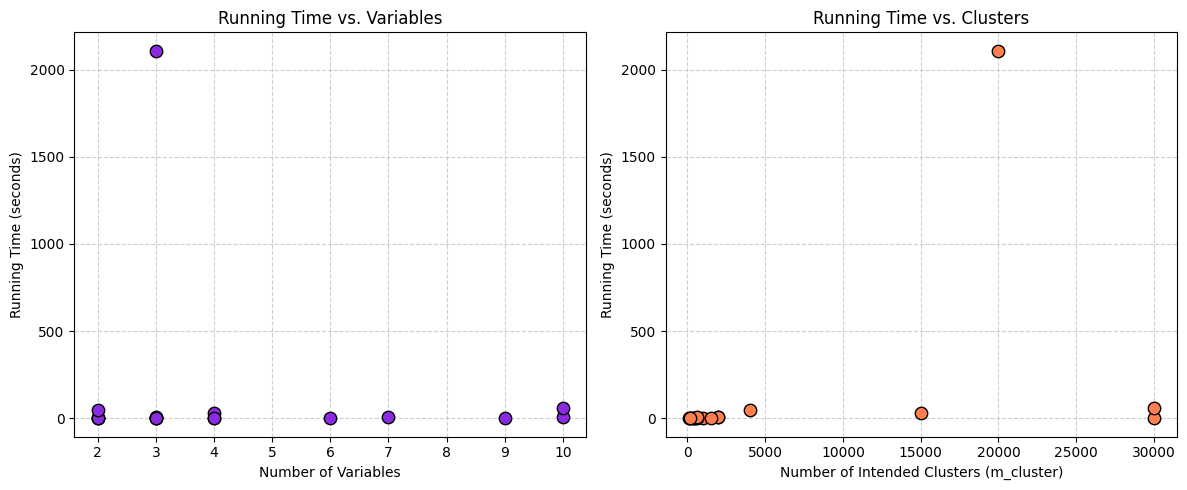

In [6]:
plt.figure(figsize=(12, 5))

# Plot 1: Runtime vs. Number of Variables
plt.subplot(1, 2, 1)
vars_list = [r['Variables (n)'] for r in results]
times_list = [r['Time (s)'] for r in results]
plt.scatter(vars_list, times_list, color='#8a2be2', edgecolor='black', s=80, zorder=3)
plt.xlabel('Number of Variables')
plt.ylabel('Running Time (seconds)')
plt.title('Running Time vs. Variables')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Runtime vs. Number of Clusters
plt.subplot(1, 2, 2)
clusters_list = [r['Clusters (m_cluster)'] for r in results]
plt.scatter(clusters_list, times_list, color='#ff7f50', edgecolor='black', s=80, zorder=3)
plt.xlabel('Number of Intended Clusters (m_cluster)')
plt.ylabel('Running Time (seconds)')
plt.title('Running Time vs. Clusters')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
